# Embedding pipeline — proof of concept

Runs the whole `evo.embeddings` pipeline over a handful of samples and plots the
result. Everything here executes on a laptop in a few seconds.

**What this proves.** VCF reading, per-sample allele reconstruction, window
construction, segment spans, strand handling, pooling, the N filter, `.npz`
storage, and that the output is shaped and aligned correctly for analysis.

**What this does not prove.** Anything about Evo 2. The model cannot run on this
machine — PyTorch ships no macOS x86_64 wheel for Python 3.13, and `evo2`
additionally needs CUDA and Python <3.13. So the model slot is filled by
`KmerEmbedder`, a *k*-mer featuriser that satisfies the same one-method
protocol.

`KmerEmbedder` is not noise: mean-pooling it yields a genuine 4-mer frequency
vector, so the structure in the plots below is real sequence structure. But it
has no context beyond 4 bases and nothing learned. **No biological conclusion
here transfers to Evo 2.** On the cluster, `Evo2Embedder(...)` replaces it and
nothing else changes.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from evo.embeddings import (
    KmerEmbedder, WindowSpec, build_window, extract, load, read_insertions, save,
)
from evo.utils import FastaReference

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
VCF = ROOT / "data/sv_output/survivor_multi_sample_vcf/first_500_INS.vcf"
NOVELTY = ROOT / "data/sv_output/survivor_multi_sample_vcf/first_500_INS.novelty.filtered.tsv"
FASTA = ROOT / "data/hg38/human_GRCh38_no_alt_analysis_set.fasta"

N_SAMPLES = 8          # how many genomes to include
MAX_WINDOWS = 200      # cap, to keep this notebook quick

# Smaller than the production default (flank=3584) purely for speed here; the
# segment structure is identical, only the flank context is shorter.
SPEC = WindowSpec(flank=1024, junction=64, repeat_crop=512)

print(f"repo: {ROOT}")
for p in (VCF, NOVELTY, FASTA):
    print(f"  {'ok ' if p.exists() else 'MISSING'} {p.relative_to(ROOT)}")

repo: /Users/andrew/orca/workspaces/novelTRs/evo2-annotation
  ok  data/sv_output/survivor_multi_sample_vcf/first_500_INS.vcf
  ok  data/sv_output/survivor_multi_sample_vcf/first_500_INS.novelty.filtered.tsv
  ok  data/hg38/human_GRCh38_no_alt_analysis_set.fasta


## 1. Read per-sample insertion alleles

Breakpoint and sequence come from the per-sample `FORMAT` fields (`CO`, `AAL`
minus `RAL`), not the record columns — the record `POS` disagrees with the
sample's own breakpoint for 59% of entries, by a median of 34 bp.

In [2]:
calls = list(read_insertions(str(VCF)))
samples = sorted({c.sample for c in calls})[:N_SAMPLES]
subset = [c for c in calls if c.sample in samples][:MAX_WINDOWS]

print(f"{len(calls)} insertion calls across {len({c.sample for c in calls})} samples")
print(f"using {len(samples)} samples: {', '.join(samples)}")
print(f"selected {len(subset)} calls")

offsets = [abs(c.pos - c.record_pos) for c in subset]
print(f"\nper-sample breakpoint vs record POS: {sum(o > 0 for o in offsets)}/{len(offsets)} differ, max {max(offsets)} bp")
print(f"insertion length: min {min(len(c.insert) for c in subset)}, max {max(len(c.insert) for c in subset)}")

6127 insertion calls across 68 samples
using 8 samples: HG00290, HG00320, HG00321, HG00329, HG00350, HG00408, HG00597, HG00609
selected 200 calls

per-sample breakpoint vs record POS: 135/200 differ, max 609 bp
insertion length: min 50, max 15866


## 2. Build windows

One window per call: reference flank, the insertion, reference flank. The five
segments are token spans within it, all available from the same forward pass.

In [3]:
reference = FastaReference(str(FASTA))
contigs = set(reference.contigs)

windows, meta = [], []
for c in subset:
    if c.chrom not in contigs:
        continue
    windows.append(build_window(reference, c.chrom, c.pos, c.insert, SPEC))
    meta.append(c)

print(f"built {len(windows)} windows")
print(f"  length: {min(len(w.sequence) for w in windows)}–{max(len(w.sequence) for w in windows)} (spec max {SPEC.max_length})")
print(f"  cropped (insertion > {SPEC.repeat_crop}): {sum(w.cropped for w in windows)}")
print(f"  >10% N: {sum(w.n_fraction > 0.1 for w in windows)}")

built 200 windows
  length: 2098–2560 (spec max 2560)
  cropped (insertion > 512): 69
  >10% N: 3


In [4]:
w, c = windows[0], meta[0]
print(f"{c.chrom}:{c.pos}  sample {c.sample}  {c.svid}  insertion {c.insert_length if hasattr(c,'insert_length') else len(c.insert)} bp\n")
for name, s in w.segments.items():
    txt = w.sequence[s.start:s.end]
    show = txt if len(txt) <= 40 else f"{txt[:18]} … {txt[-18:]}"
    print(f"  {name:12} [{s.start:>5},{s.end:>5})  len {len(s):>4}  {show}")

chr1:10862  sample HG00329  Sniffles2.INS.5S0  insertion 162 bp

  left         [    0, 1024)  len 1024  NNNNNNNNNNNNNNNNNN … AGGCGCGCCGCGCCGGCG
  junction_5p  [  960, 1088)  len  128  GACACATGCTAGCGCGTC … GCCGCGCCGGCGCAGGCG
  repeat       [ 1024, 1186)  len  162  CAGGCGCAGAGAGGCGCG … CAGGGAGGAGGCGTGGCA
  junction_3p  [ 1122, 1250)  len  128  AGGCGCGCCGCGCCGGCG … GCAGGCGCAGAGAGGCGC
  right        [ 1186, 2210)  len 1024  CAGGCGCAGAGACACATG … GTTAACTTGCCGTCAGCC


## 3. Extract

Two passes per window — forward and reverse complement — pooled into one vector
per (layer, segment). Regions use `mean`, breakpoints use `last`.

`KmerEmbedder` returns identical features for every layer, so this uses a single
layer. On real Evo 2 the layer axis is where depth shows up, and extra layers
are nearly free because they come from the same pass.

In [5]:
embedder = KmerEmbedder(k=4)
LAYERS = ["kmer4"]
SEGMENTS = ["left", "junction_5p", "repeat", "junction_3p", "right"]

vectors, kept = extract(windows, embedder, layers=LAYERS, segments=SEGMENTS,
                        max_n_fraction=0.1)
keep = {id(w): m for w, m in zip(windows, meta)}
kept_meta = [keep[id(w)] for w in kept]

print(f"vectors {vectors.shape}  = (windows, layers, segments, 2 × {embedder.width})")
print(f"kept {len(kept)} of {len(windows)}  (dropped {len(windows) - len(kept)} N-heavy)")

vectors (197, 1, 5, 512)  = (windows, layers, segments, 2 × 256)
kept 197 of 200  (dropped 3 N-heavy)


## 4. Round-trip through storage

This is the actual handoff between machines: the cluster writes this file, a
laptop reads it. Metadata travels with the vectors so rows stay interpretable.

In [6]:
out = ROOT / "notebooks" / "poc_embeddings.npz"
save(str(out), vectors, kept, LAYERS, SEGMENTS,
     samples=[m.sample for m in kept_meta],
     svids=[m.svid for m in kept_meta],
     attrs={"model": "KmerEmbedder(k=4) — NOT Evo 2", "flank": str(SPEC.flank)})

e = load(str(out))
print(f"wrote {out.name}: {out.stat().st_size/1e6:.2f} MB")
print(f"  vectors {e.vectors.shape} {e.vectors.dtype}")
print(f"  attrs {e.attrs}")
print(f"  view('kmer4', 'repeat') -> {e.view('kmer4', 'repeat').shape}")

wrote poc_embeddings.npz: 0.10 MB
  vectors (197, 1, 5, 512) float16
  attrs {'flank': '1024', 'format_version': '1', 'model': 'KmerEmbedder(k=4) — NOT Evo 2'}
  view('kmer4', 'repeat') -> (197, 512)


## 5. Do the segments separate?

The first real question the pipeline can answer. Each segment is pooled from a
different part of the same window, so if the plumbing is right they should
occupy different regions: `repeat` sees inserted tandem repeat, `left`/`right`
see ordinary genome, junctions see a mix.

PCA rather than UMAP here — the axes mean something, and with a few hundred
points UMAP would invent structure.

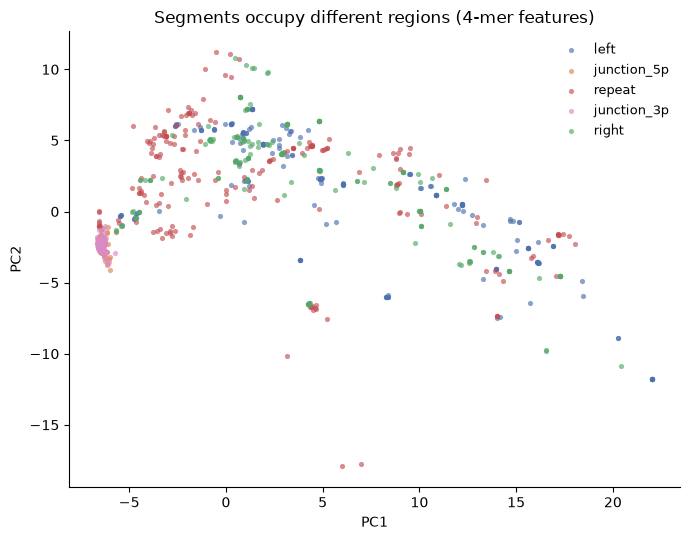

In [7]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

X = np.concatenate([e.view("kmer4", s) for s in SEGMENTS]).astype(np.float32)
labels = np.repeat(SEGMENTS, len(e))
Z = PCA(n_components=2, random_state=0).fit_transform(StandardScaler().fit_transform(X))

fig, ax = plt.subplots(figsize=(7, 5.5))
colors = dict(zip(SEGMENTS, ["#4C72B0", "#DD8452", "#C44E52", "#DA8BC3", "#55A868"]))
for s in SEGMENTS:
    m = labels == s
    ax.scatter(Z[m, 0], Z[m, 1], s=14, alpha=.65, label=s, c=colors[s], linewidths=0)
ax.set(xlabel="PC1", ylabel="PC2", title="Segments occupy different regions (4-mer features)")
ax.legend(frameon=False, fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## 6. Clustering, and the length confound

KMeans on the `repeat` segment. The point of colouring by insertion length is
that clusters in this kind of space are often *just* length — checking it is
cheap, and `insert_length` is stored pre-crop precisely so it can be checked.

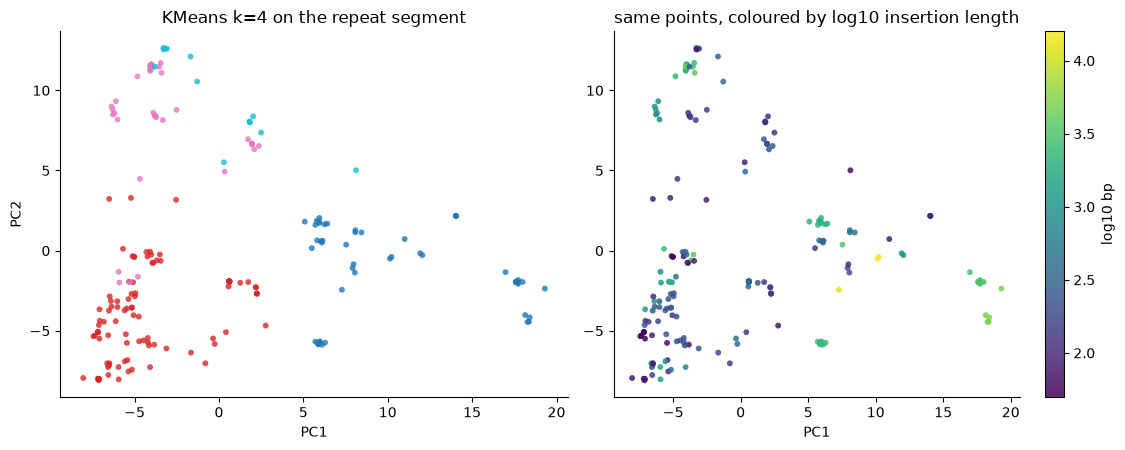

cluster 0: n=  50  median insertion    2180 bp
cluster 1: n=  95  median insertion     202 bp
cluster 2: n=  38  median insertion     850 bp
cluster 3: n=  14  median insertion     118 bp


In [8]:
from sklearn.cluster import KMeans

R = StandardScaler().fit_transform(e.view("kmer4", "repeat").astype(np.float32))
Zr = PCA(n_components=2, random_state=0).fit_transform(R)
km = KMeans(n_clusters=4, n_init=10, random_state=0).fit_predict(R)
lengths = e.meta["insert_length"]

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.6))
axes[0].scatter(Zr[:, 0], Zr[:, 1], c=km, cmap="tab10", s=18, alpha=.8, linewidths=0)
axes[0].set(title="KMeans k=4 on the repeat segment", xlabel="PC1", ylabel="PC2")

sc = axes[1].scatter(Zr[:, 0], Zr[:, 1], c=np.log10(lengths), cmap="viridis",
                     s=18, alpha=.85, linewidths=0)
axes[1].set(title="same points, coloured by log10 insertion length", xlabel="PC1")
fig.colorbar(sc, ax=axes[1], label="log10 bp")
for a in axes:
    a.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

for c_ in sorted(set(km)):
    m = km == c_
    print(f"cluster {c_}: n={m.sum():>4}  median insertion {np.median(lengths[m]):>7.0f} bp")

## 7. Novel vs known

Joining the novelty verdicts on `(chrom, record_pos, SVID, sample)` — the record
position, because that is the coordinate `sv_trfcaller.py` wrote. `record_pos`
is carried on every call for exactly this purpose.

With 4-mer features this comparison is a **plumbing check, not a result**: it
shows labels reach the right rows. Whether novel and known loci actually
separate is an Evo 2 question.

  known        22
  novel_motif  3
  unlabelled   172


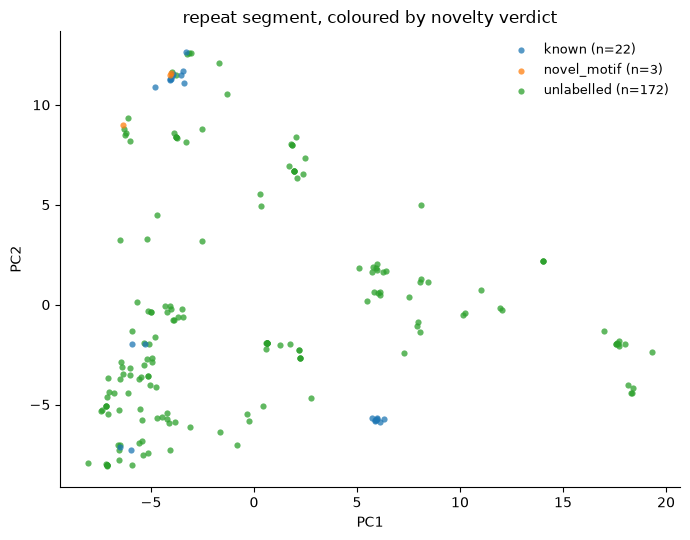

In [9]:
import csv

verdict = {}
with open(NOVELTY) as fh:
    for row in csv.DictReader(fh, delimiter="\t"):
        verdict[(row["chrom"], int(row["ins_coord"]), row["SVID"], row["sample"])] = row["novelty"]

labels = np.array([
    verdict.get((m.chrom, m.record_pos, m.svid, m.sample), "unlabelled")
    for m in kept_meta
])
for name, n in zip(*np.unique(labels, return_counts=True)):
    print(f"  {name:12} {n}")

known = {"known", "novel_motif", "novel_locus"}
fig, ax = plt.subplots(figsize=(7, 5.5))
for name in np.unique(labels):
    m = labels == name
    ax.scatter(Zr[m, 0], Zr[m, 1], s=20, alpha=.75, label=f"{name} (n={m.sum()})",
               linewidths=0, zorder=2 if name in known else 1)
ax.set(title="repeat segment, coloured by novelty verdict", xlabel="PC1", ylabel="PC2")
ax.legend(frameon=False, fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## What changes on the cluster

One line:

```python
from evo.embeddings import Evo2Embedder
embedder = Evo2Embedder("evo2_7b_base")          # instead of KmerEmbedder(k=4)
LAYERS = list(LAYER_SETS["default"])             # 9 layers, same forward pass
SPEC = WindowSpec()                              # flank=3584, fits the 8192 context
```

Everything downstream — extraction, storage, PCA, clustering, the label join —
is unchanged. Or from the shell:

```bash
uv run evo-embed calls.vcf hg38.fasta out.npz --layers default
```

Budget for the full callset at `d_model` 4096: 6,083 windows × 9 layers ×
5 segments ≈ **4.5 GB** in float16, and 12,166 forward passes of ~8k tokens.